In [1]:
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
jobs = pd.read_csv("../data/processed/jobs_clean.csv")
skills = pd.read_csv("../data/processed/skills_clean.csv")

df = jobs.merge(skills, on="job_id")

skill
TensorFlow         876
GCP                868
R                  858
AWS                853
Azure              853
Python             852
NLP                842
SQL                823
Scikit-learn       821
Computer Vision    817
PyTorch            797
Name: count, dtype: int64

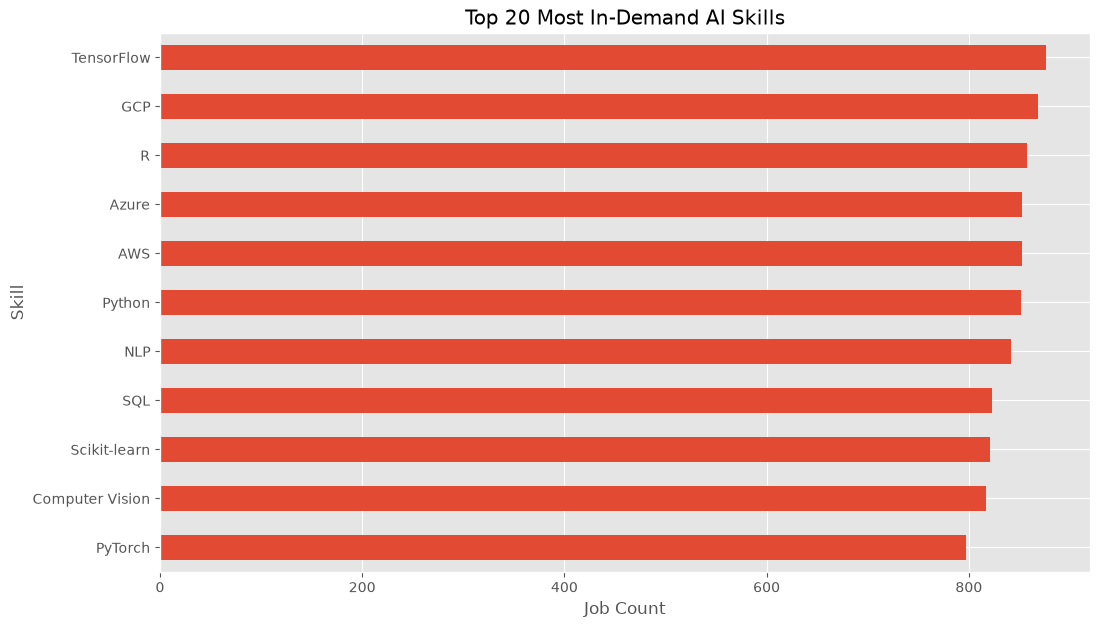

In [3]:
top_skills = df["skill"].value_counts().head(20)

display(top_skills)

plt.figure(figsize=(12,7))
top_skills.sort_values().plot(kind="barh")
plt.title("Top 20 Most In-Demand AI Skills")
plt.xlabel("Job Count")
plt.ylabel("Skill")
plt.show()

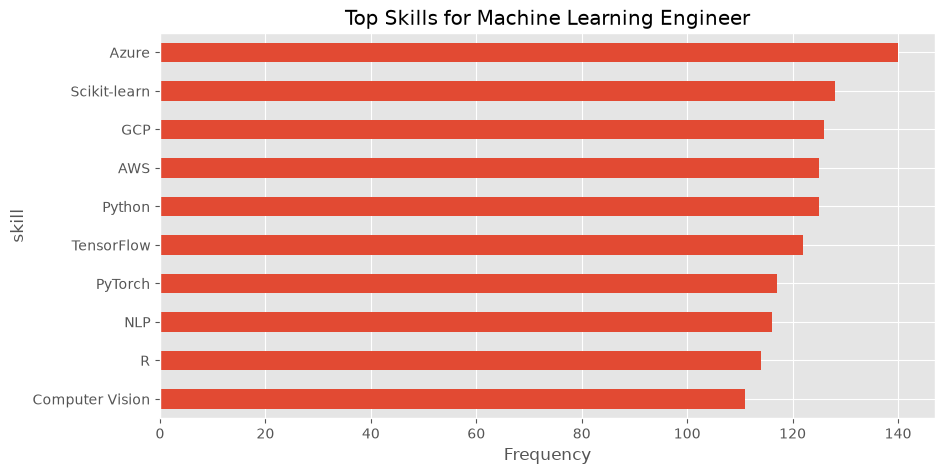

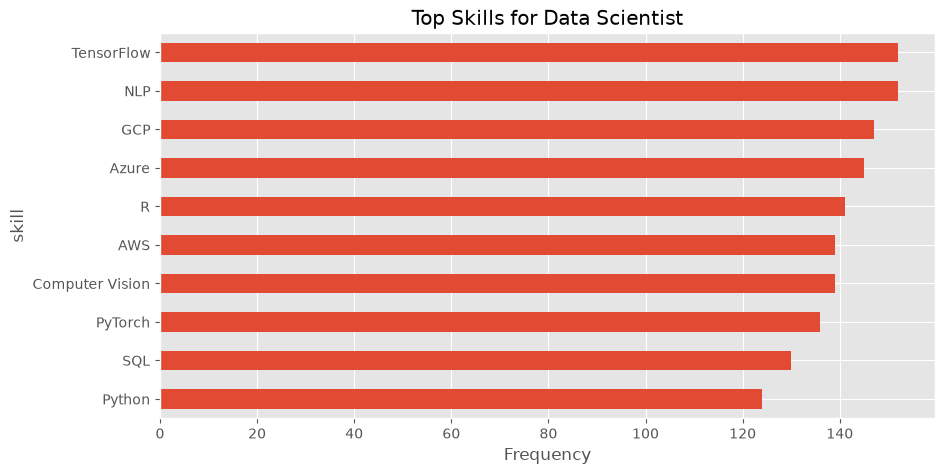

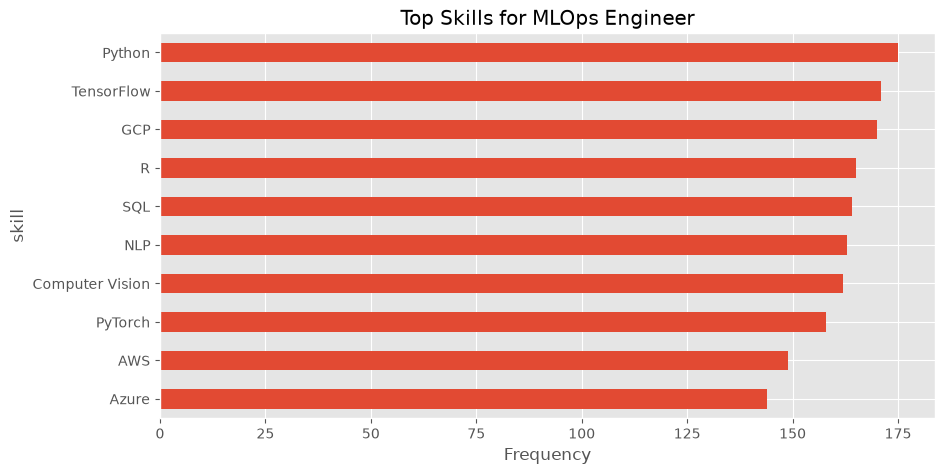

In [4]:
top_roles = [
    "AI Engineer",
    "Machine Learning Engineer",
    "Data Scientist",
    "NLP Engineer",
    "Computer Vision Engineer",
    "MLOps Engineer"
]

for role in top_roles:
    role_df = df[df["job_title"] == role]

    if len(role_df) == 0:
        continue

    plt.figure(figsize=(10,5))

    (
        role_df["skill"]
        .value_counts()
        .head(10)
        .sort_values()
        .plot(kind="barh")
    )

    plt.title(f"Top Skills for {role}")
    plt.xlabel("Frequency")
    plt.show()

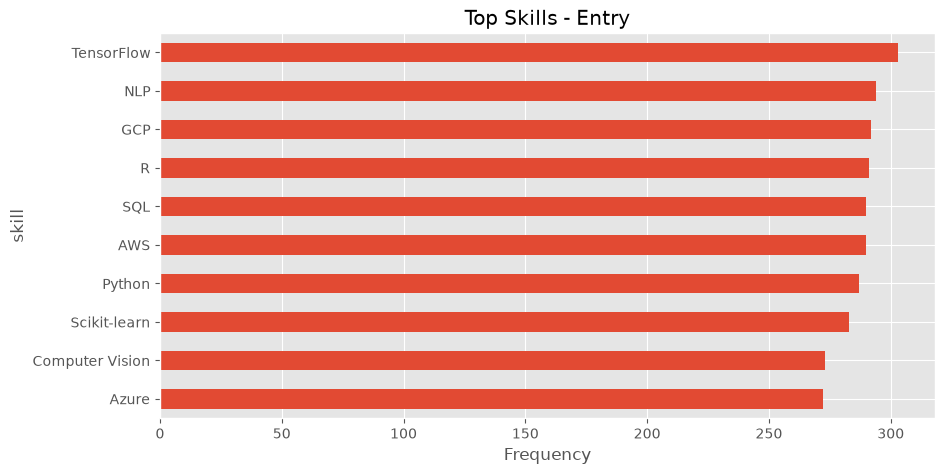

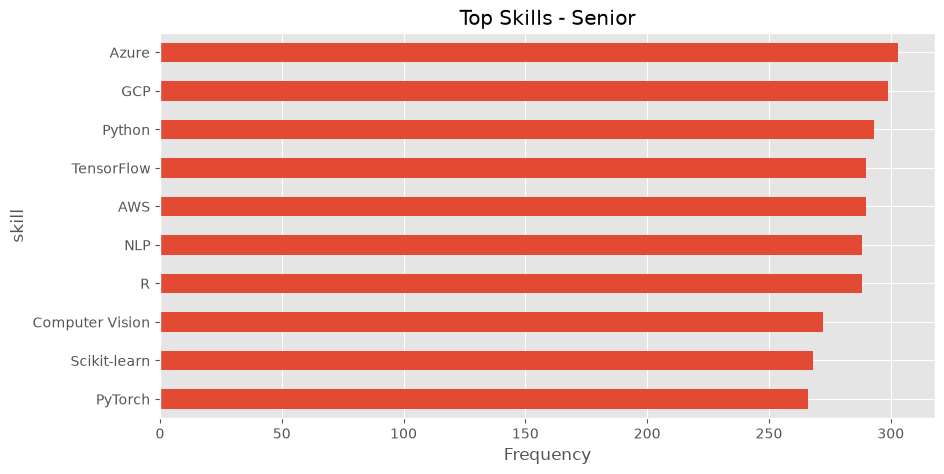

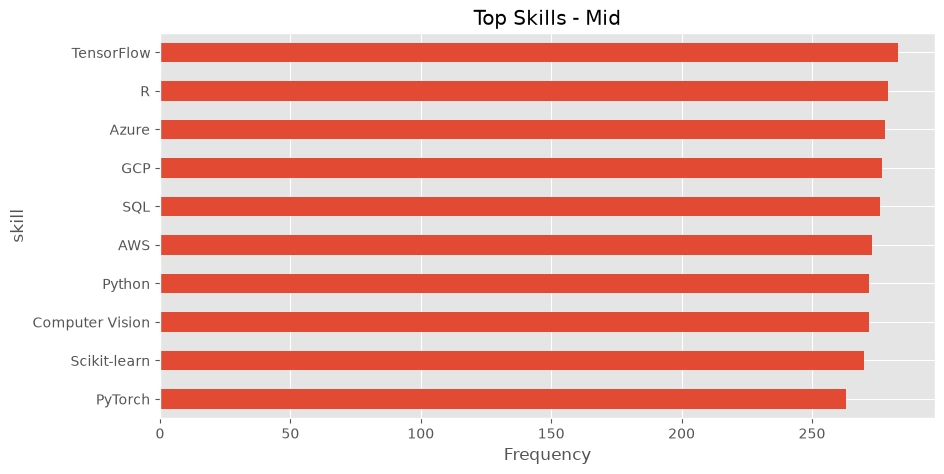

In [5]:
experience_levels = df["experience_level"].unique()

for level in experience_levels:

    level_df = df[df["experience_level"] == level]

    plt.figure(figsize=(10,5))

    (
        level_df["skill"]
        .value_counts()
        .head(10)
        .sort_values()
        .plot(kind="barh")
    )

    plt.title(f"Top Skills - {level}")
    plt.xlabel("Frequency")
    plt.show()

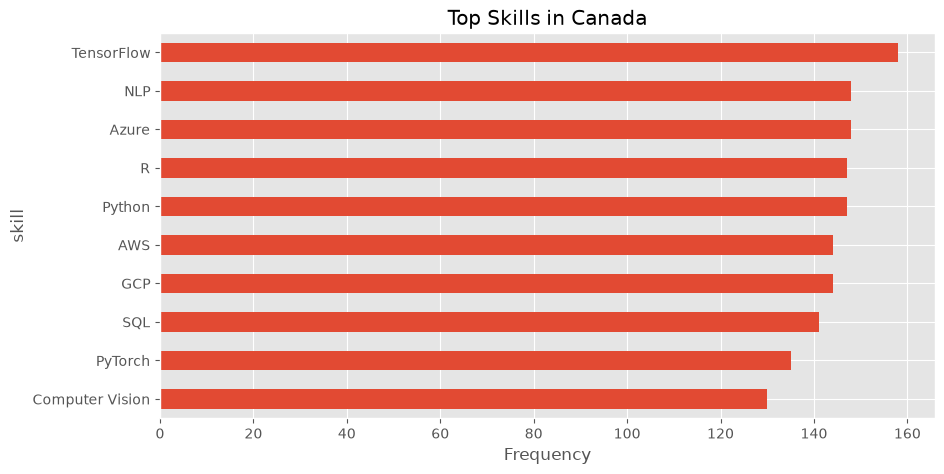

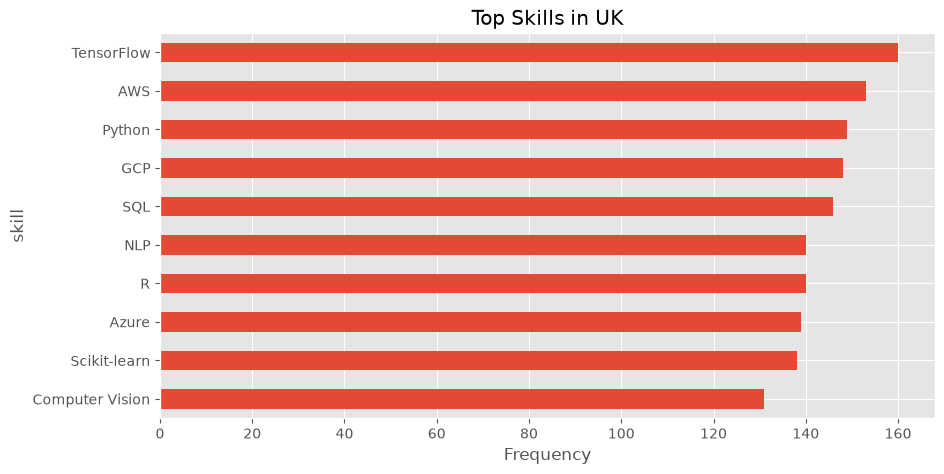

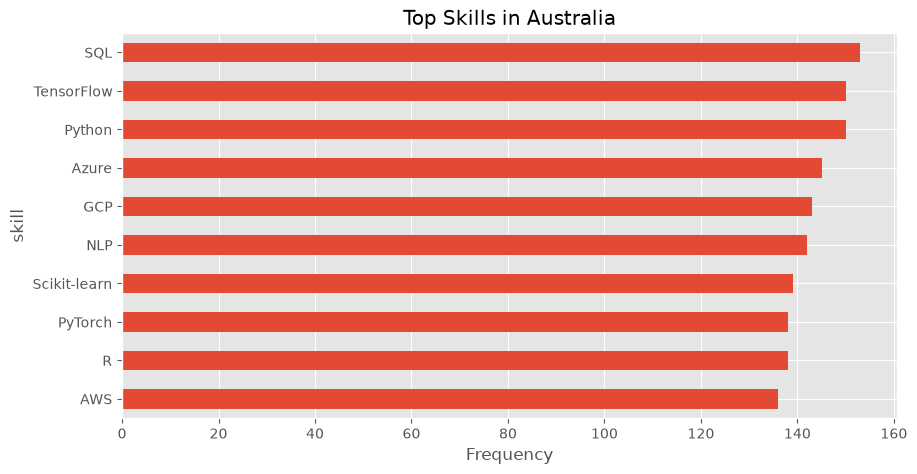

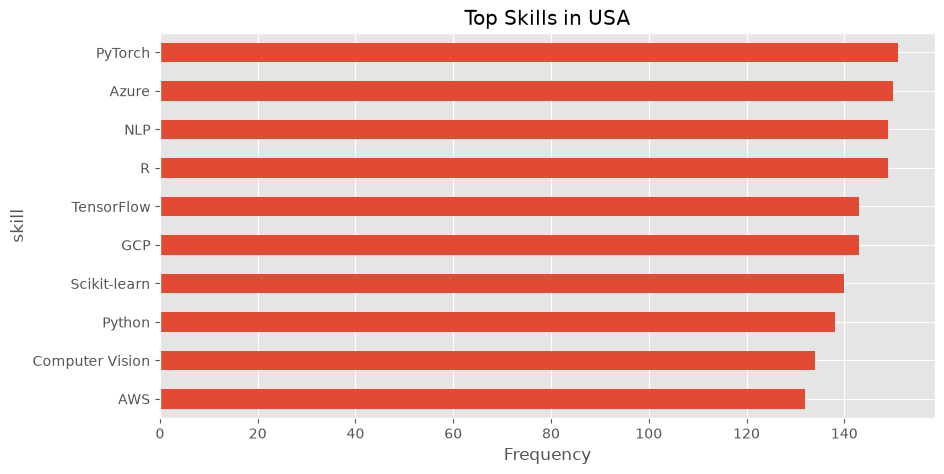

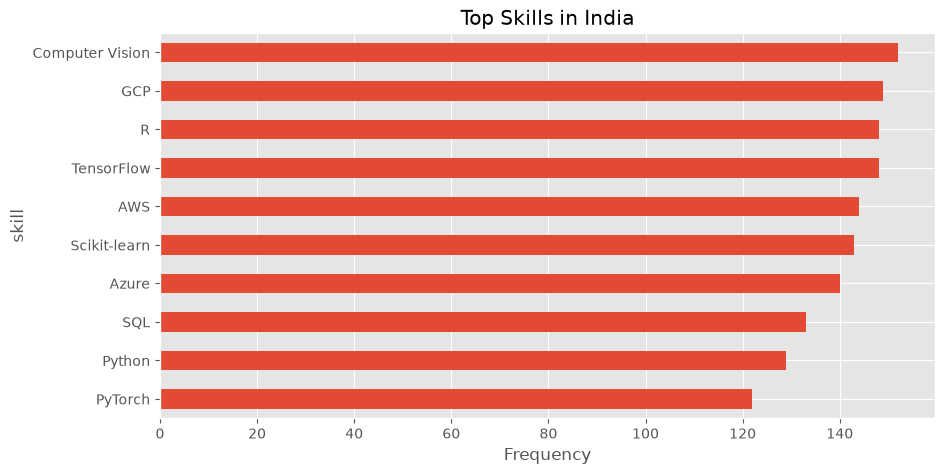

In [6]:
top_countries = df["country"].value_counts().head(5).index

for country in top_countries:

    country_df = df[df["country"] == country]

    plt.figure(figsize=(10,5))

    (
        country_df["skill"]
        .value_counts()
        .head(10)
        .sort_values()
        .plot(kind="barh")
    )

    plt.title(f"Top Skills in {country}")
    plt.xlabel("Frequency")
    plt.show()

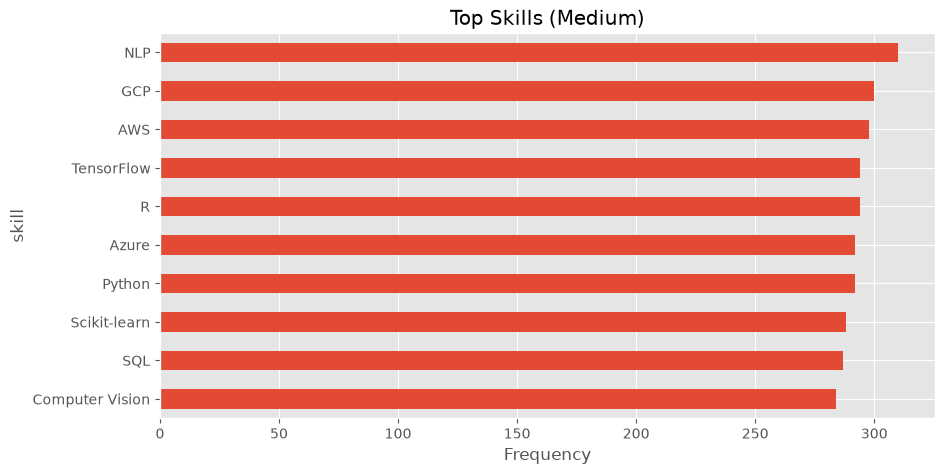

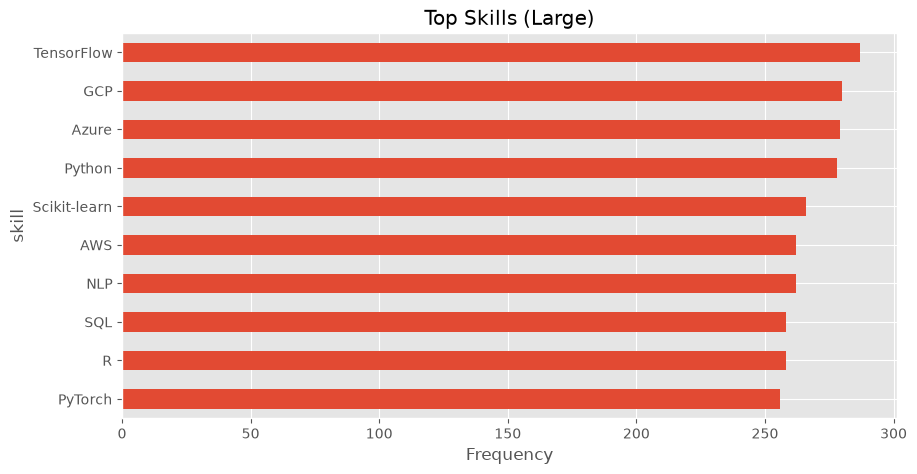

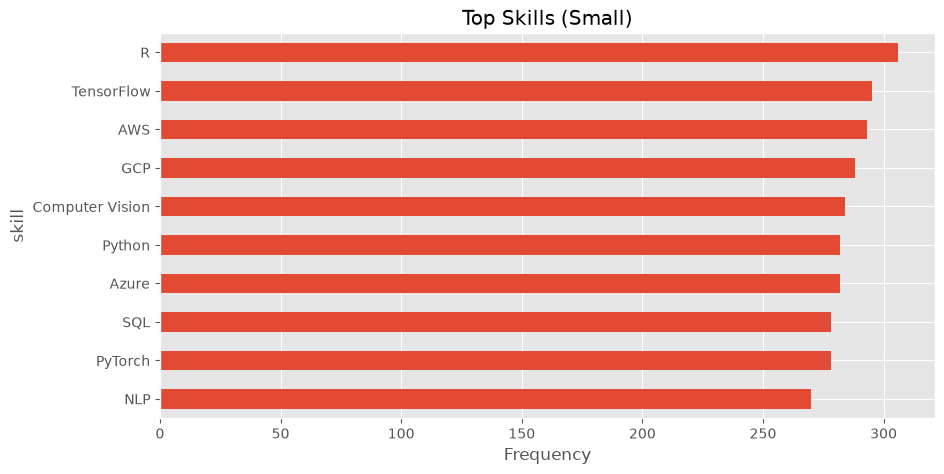

In [7]:
company_sizes = df["company_size"].unique()

for size in company_sizes:

    size_df = df[df["company_size"] == size]

    plt.figure(figsize=(10,5))

    (
        size_df["skill"]
        .value_counts()
        .head(10)
        .sort_values()
        .plot(kind="barh")
    )

    plt.title(f"Top Skills ({size})")
    plt.xlabel("Frequency")
    plt.show()

skill
Azure              112320.055686
Python             111274.002347
GCP                111141.213134
AWS                111000.444900
PyTorch            110839.628607
Computer Vision    110791.023256
R                  110729.612471
NLP                110660.401425
TensorFlow         110112.894406
Scikit-learn       109922.414738
SQL                108875.513973
Name: average_salary, dtype: float64

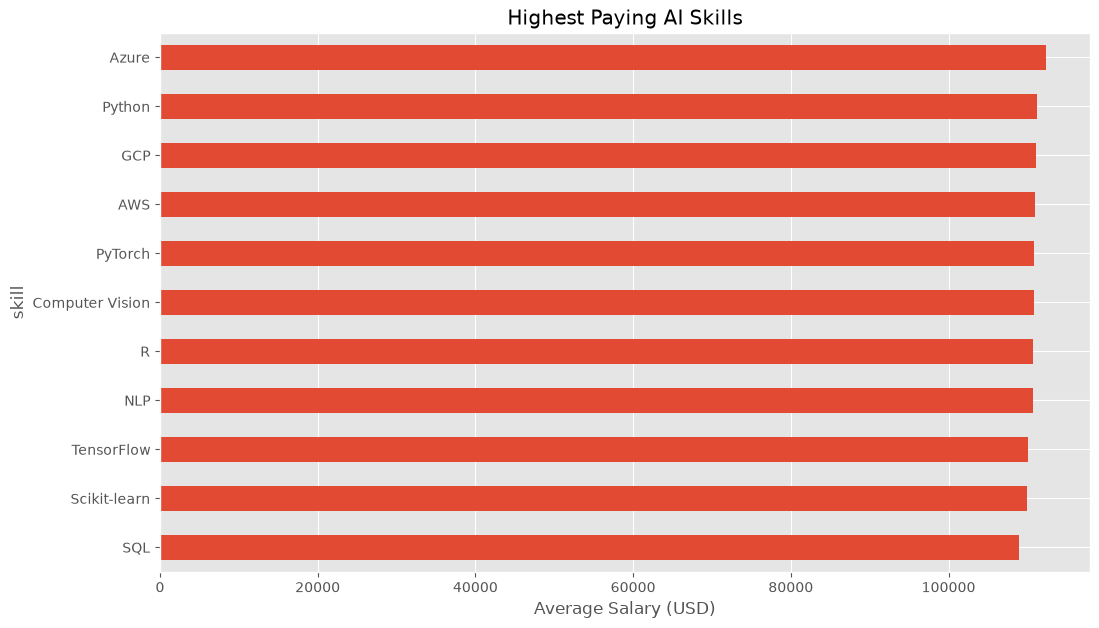

In [8]:
df["average_salary"] = (
    df["salary_min_usd"] + df["salary_max_usd"]
) / 2

salary_skill = (
    df.groupby("skill")["average_salary"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

display(salary_skill)

plt.figure(figsize=(12,7))
salary_skill.sort_values().plot(kind="barh")
plt.title("Highest Paying AI Skills")
plt.xlabel("Average Salary (USD)")
plt.show()

job_title
Applied Scientist            111382.242167
Data Analyst                 111343.315133
Machine Learning Engineer    110816.692345
Data Scientist               110740.231570
AI Researcher                110574.632620
MLOps Engineer               110348.288541
Name: average_salary, dtype: float64

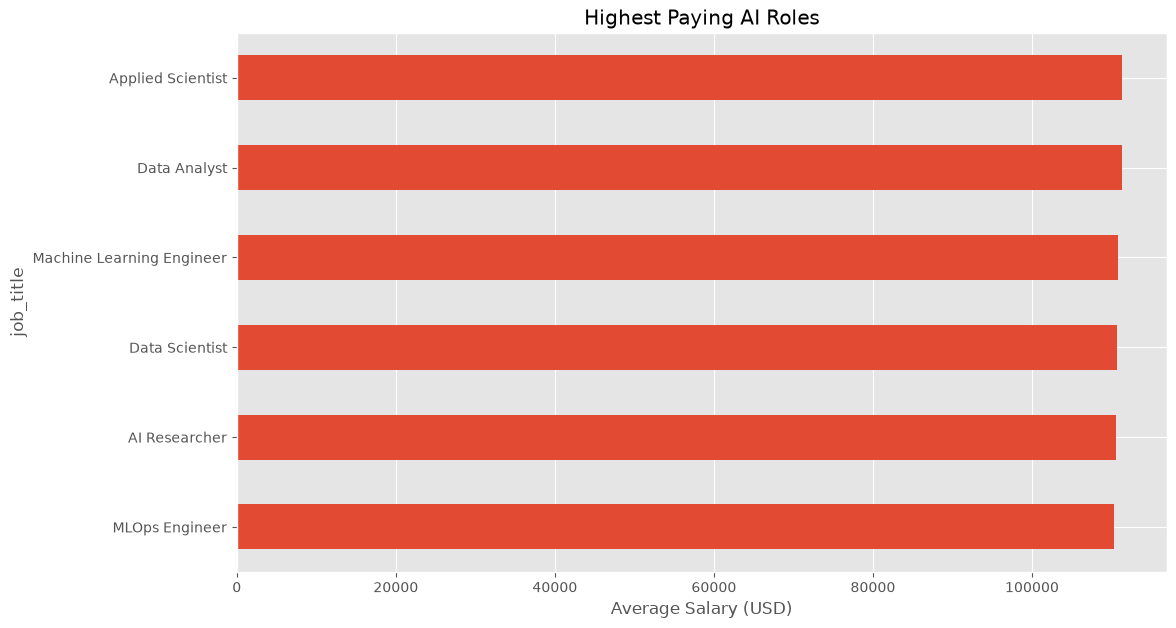

In [9]:
salary_role = (
    jobs.assign(
        average_salary=(jobs["salary_min_usd"] + jobs["salary_max_usd"]) / 2
    )
    .groupby("job_title")["average_salary"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

display(salary_role)

plt.figure(figsize=(12,7))
salary_role.sort_values().plot(kind="barh")
plt.title("Highest Paying AI Roles")
plt.xlabel("Average Salary (USD)")
plt.show()

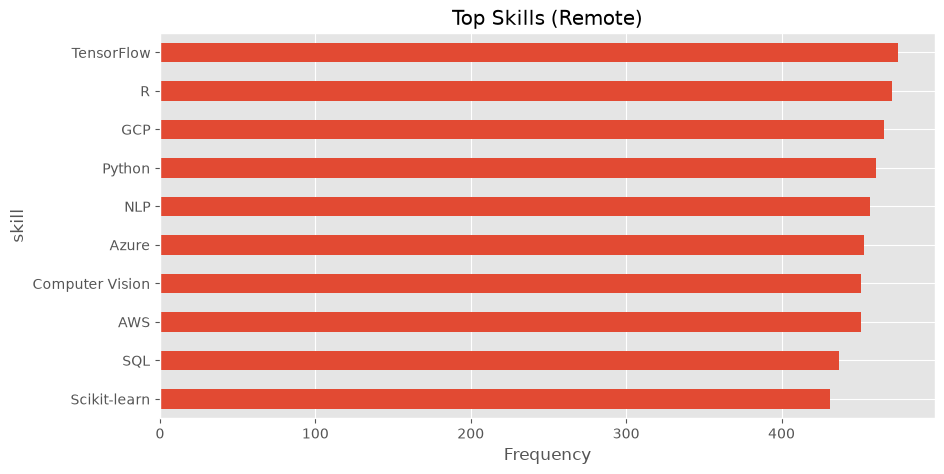

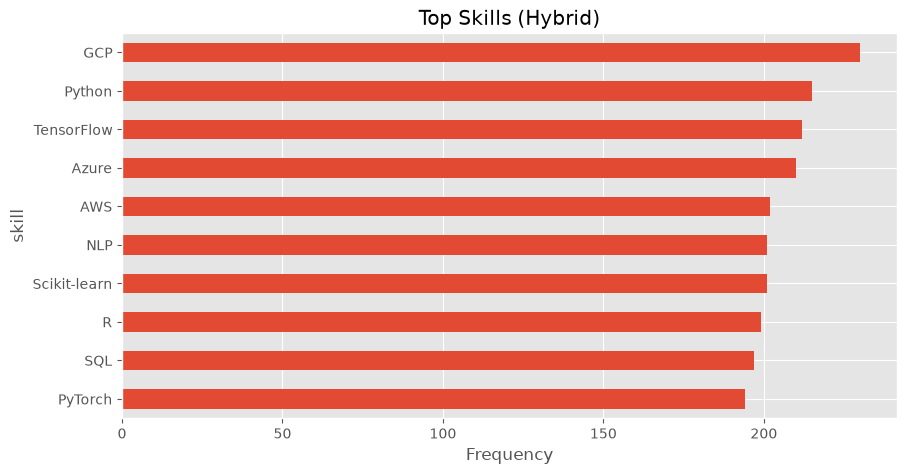

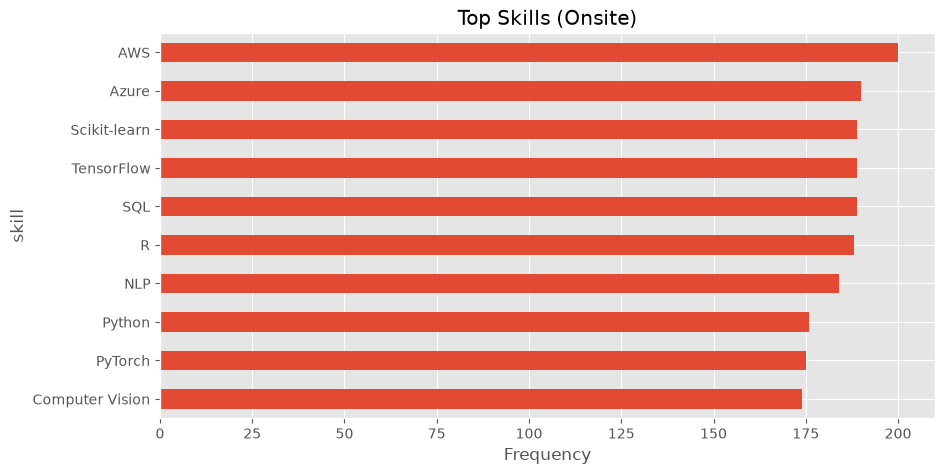

In [10]:
remote_types = df["remote_type"].unique()

for mode in remote_types:

    mode_df = df[df["remote_type"] == mode]

    plt.figure(figsize=(10,5))

    (
        mode_df["skill"]
        .value_counts()
        .head(10)
        .sort_values()
        .plot(kind="barh")
    )

    plt.title(f"Top Skills ({mode})")
    plt.xlabel("Frequency")
    plt.show()

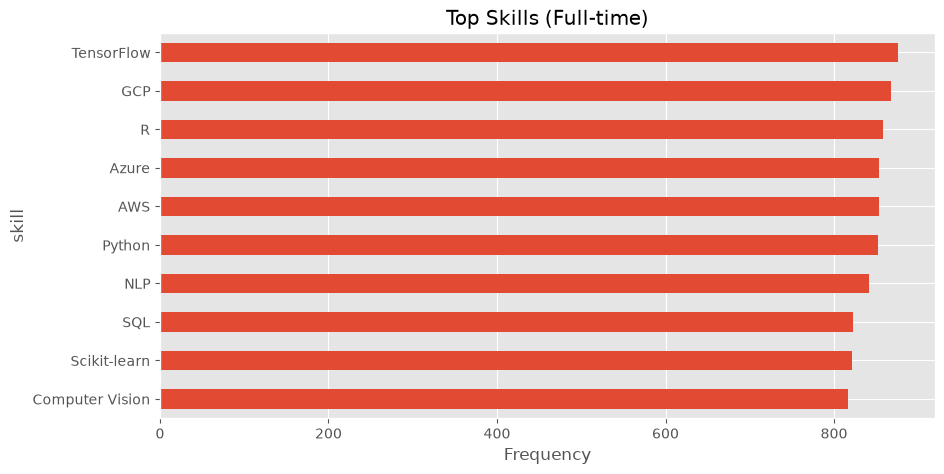

In [11]:
employment_types = df["employment_type"].unique()

for emp in employment_types:

    emp_df = df[df["employment_type"] == emp]

    plt.figure(figsize=(10,5))

    (
        emp_df["skill"]
        .value_counts()
        .head(10)
        .sort_values()
        .plot(kind="barh")
    )

    plt.title(f"Top Skills ({emp})")
    plt.xlabel("Frequency")
    plt.show()

skill_category
ML             4153
Cloud          2574
Programming    2533
Name: count, dtype: int64

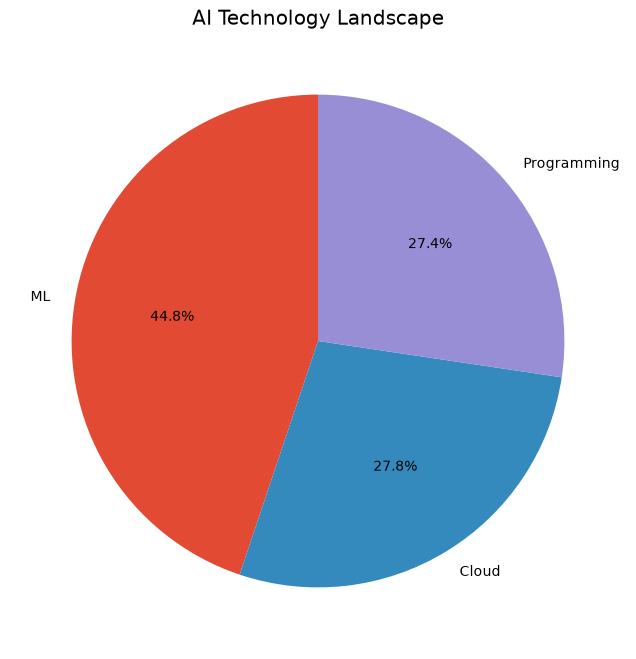

In [12]:
skill_category = df["skill_category"].value_counts()

display(skill_category)

plt.figure(figsize=(8,8))

plt.pie(
    skill_category.values,
    labels=skill_category.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("AI Technology Landscape")
plt.show()